In [1]:
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import math

import import_ipynb
from graph_functions import *

In [2]:
# number of graphs for n=4 a=1: 1
# number of graphs for n=6 a=2: 2
# number of graphs for n=8 a=3: 1
# number of graphs for n=10 a=4: 2
# number of graphs for n=12 a=5: 1
# number of graphs for n=14 a=6: 2
# number of graphs for n=16 a=7: 1
# number of graphs for n=18 a=8: 2

In [3]:
def partitions(n, k, p=1):
	if n < p: return
	elif k == 0:
		if n == 0: yield []
	elif k == 1:
		if n != 0: yield [n]
	else:
		for r in partitions(n-p, k-1, p):
			yield [p] + r
		yield from partitions(n, k, p + 1)


def infect_cycle(n, k):
	for l in range(1, k + 1):
		for r in partitions(k, l):
			for p in partitions(n - k, l):
				s = []
				for b, b2 in zip(r, p):
					# s += "1" * int(b) + "0" * int(b2)
					s.extend([1] * int(b))
					s.extend([0] * int(b2))
				yield s

def generate_infection_mobious(G):
    pass

def rotate_mask(mask, shift):
    n = len(mask)
    return mask[shift:] + mask[:shift]

def generate_infection_prism(G):
    n = len(G.nodes)
    n_half = n // 2

    for k in range(2, n):
        for k1 in range(1, k):
            k2 = k - k1

            top_infections = infection_graph_permuation([0]*n_half, k1)
            bottom_infections = infection_graph_permuation([0]*n_half, k2)

            for t in top_infections:
                for b in bottom_infections:
                    for shift in range(n_half):
                        yield t + rotate_mask(b, shift)


def generate_infection_prism2(G):
    n = len(G.nodes)
    n_half = n // 2

    for k in range(2, n):
        for k1 in range(1, k):
            k2 = k - k1

            top = infection_graph_permuation([0]*n_half, k1)
            bottom = infection_graph_permuation([0]*n_half, k2)

            for t in top:
                for b in bottom:
                    yield t + b


In [4]:
graphs = generate_graphs(8)[1:]
# Using it
graph_infections = []
for G, n, a in graphs:
    unique_infections = []
    for infection_mask in generate_infection_prism(G):
        print(infection_mask)
        H = infect_graph(G, infection_mask)
        H_full, _, _ = fully_endemic(H)
        unique_infections.append((H, n, a))
        unique_infections.append((H_full, n, a))
    
    graph_infections.append(unique_infections)
    # display_graphs(unique_infections, figsize=(5, 5), show_titles=True, force_row=False)

number of graphs for n=8 : 1


In [5]:
i_list1 = graph_infections[0][:2]

display_graphs(i_list1, figsize=(5, 5), show_titles=True, force_row=False, with_labels=True)

IndexError: list index out of range

In [6]:
x = generate_graphs(10)
G, _, _ = x[1]

# for G, _, _ in x:
#     display_graph(G, figsize=(3, 3), show_title=True, with_labels=True)

number of graphs for n=10 : 2


In [99]:
for im in generate_infection_prism2(G):
    print(im)

[1, 0, 0, 0, 0, 1, 0, 0, 0, 0]
[1, 0, 0, 0, 0, 0, 1, 0, 0, 0]
[1, 0, 0, 0, 0, 0, 0, 1, 0, 0]
[1, 0, 0, 0, 0, 0, 0, 0, 1, 0]
[1, 0, 0, 0, 0, 0, 0, 0, 0, 1]
[1, 0, 0, 0, 0, 1, 1, 0, 0, 0]
[1, 0, 0, 0, 0, 1, 0, 1, 0, 0]
[1, 0, 0, 0, 0, 1, 0, 0, 1, 0]
[1, 0, 0, 0, 0, 1, 0, 0, 0, 1]
[1, 0, 0, 0, 0, 0, 1, 1, 0, 0]
[1, 0, 0, 0, 0, 0, 1, 0, 1, 0]
[1, 0, 0, 0, 0, 0, 1, 0, 0, 1]
[1, 0, 0, 0, 0, 0, 0, 1, 1, 0]
[1, 0, 0, 0, 0, 0, 0, 1, 0, 1]
[1, 0, 0, 0, 0, 0, 0, 0, 1, 1]
[1, 1, 0, 0, 0, 1, 0, 0, 0, 0]
[1, 1, 0, 0, 0, 0, 1, 0, 0, 0]
[1, 1, 0, 0, 0, 0, 0, 1, 0, 0]
[1, 1, 0, 0, 0, 0, 0, 0, 1, 0]
[1, 1, 0, 0, 0, 0, 0, 0, 0, 1]
[1, 0, 0, 0, 0, 1, 1, 1, 0, 0]
[1, 0, 0, 0, 0, 1, 1, 0, 1, 0]
[1, 0, 0, 0, 0, 1, 1, 0, 0, 1]
[1, 0, 0, 0, 0, 1, 0, 1, 1, 0]
[1, 0, 0, 0, 0, 1, 0, 1, 0, 1]
[1, 0, 0, 0, 0, 1, 0, 0, 1, 1]
[1, 0, 0, 0, 0, 0, 1, 1, 1, 0]
[1, 0, 0, 0, 0, 0, 1, 1, 0, 1]
[1, 0, 0, 0, 0, 0, 1, 0, 1, 1]
[1, 0, 0, 0, 0, 0, 0, 1, 1, 1]
[1, 1, 0, 0, 0, 1, 1, 0, 0, 0]
[1, 1, 0, 0, 0, 1, 0, 1, 0, 0]
[1, 1, 0

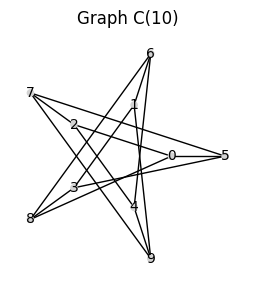

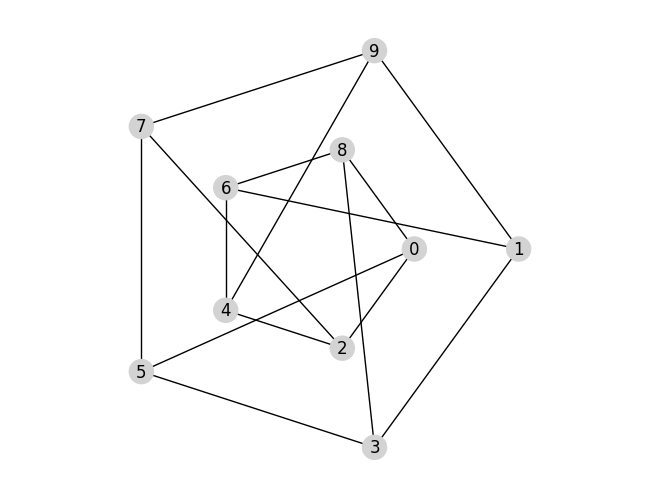

In [17]:
# display_graph(G, figsize=(3, 3), show_title=True, with_labels=True)


def get_cycles(G):
    even_nodes = [v for v in G.nodes if v % 2 == 0]
    odd_nodes  = [v for v in G.nodes if v % 2 == 1]
    
    def cycle_subgraph(G, nodes):
        n = len(nodes)
        edges = [
            (nodes[i], nodes[(i+1) % n])
            for i in range(n)
        ]
        # print(edges)
        return G.edge_subgraph(edges)
    
    
    C_top    = cycle_subgraph(G, even_nodes)
    C_bottom = cycle_subgraph(G, odd_nodes)

    return C_top, C_bottom 

def split_mask(G, mask):
    n_half = len(G) // 2
    return mask[n_half:], mask[:n_half]


# display_graph(C_top, figsize=(3,3), show_title=True, with_labels=True, pos=nx.circular_layout(C_top))
# display_graph(C_bottom, figsize=(3,3), show_title=True, with_labels=True, pos=nx.circular_layout(C_bottom))

display_graph(G, figsize=(3,3), show_title=True, with_labels=True, pos=prism_layout(G))


def ordered_cycle_nodes(C):
    nodes = list(C.nodes)
    start = nodes[0]

    order = [start]
    prev = None
    curr = start

    while True:
        nbrs = list(C.neighbors(curr))
        nxt = nbrs[0] if nbrs[0] != prev else nbrs[1]
        if nxt == start:
            break
        order.append(nxt)
        prev, curr = curr, nxt

    return order


import math

def display_prism(G, r_inner=1.0, r_outer=2.0):
    C_top, C_bottom = get_cycles(G)

    top_nodes = ordered_cycle_nodes(C_top)
    bottom_nodes = ordered_cycle_nodes(C_bottom)

    if len(top_nodes) != len(bottom_nodes):
        raise ValueError("Top and bottom cycles must have same length")

    n = len(top_nodes)
    pos = {}

    for i in range(n):
        angle = 2 * math.pi * i / n

        pos[top_nodes[i]] = (
            r_inner * math.cos(angle),
            r_inner * math.sin(angle)
        )

        pos[bottom_nodes[i]] = (
            r_outer * math.cos(angle),
            r_outer * math.sin(angle)
        )

    nx.draw(
        G,
        pos,
        with_labels=True,
        node_size=300,
        node_color=[
            'red' if G.nodes[v].get("infected") else 'lightgray'
            for v in G
        ],
    )

    plt.axis("equal")
    plt.show()


display_prism(G)

[1, 0, 0, 0, 0, 1, 0, 0, 0, 0]
[1, 0, 0, 0, 0, 0, 1, 0, 0, 0]
[1, 0, 0, 0, 0, 0, 0, 1, 0, 0]
[1, 0, 0, 0, 0, 0, 0, 0, 1, 0]
[1, 0, 0, 0, 0, 0, 0, 0, 0, 1]
[1, 0, 0, 0, 0, 1, 1, 0, 0, 0]
[1, 0, 0, 0, 0, 1, 0, 1, 0, 0]
[1, 0, 0, 0, 0, 1, 0, 0, 1, 0]
[1, 0, 0, 0, 0, 1, 0, 0, 0, 1]
[1, 0, 0, 0, 0, 0, 1, 1, 0, 0]
[1, 0, 0, 0, 0, 0, 1, 0, 1, 0]


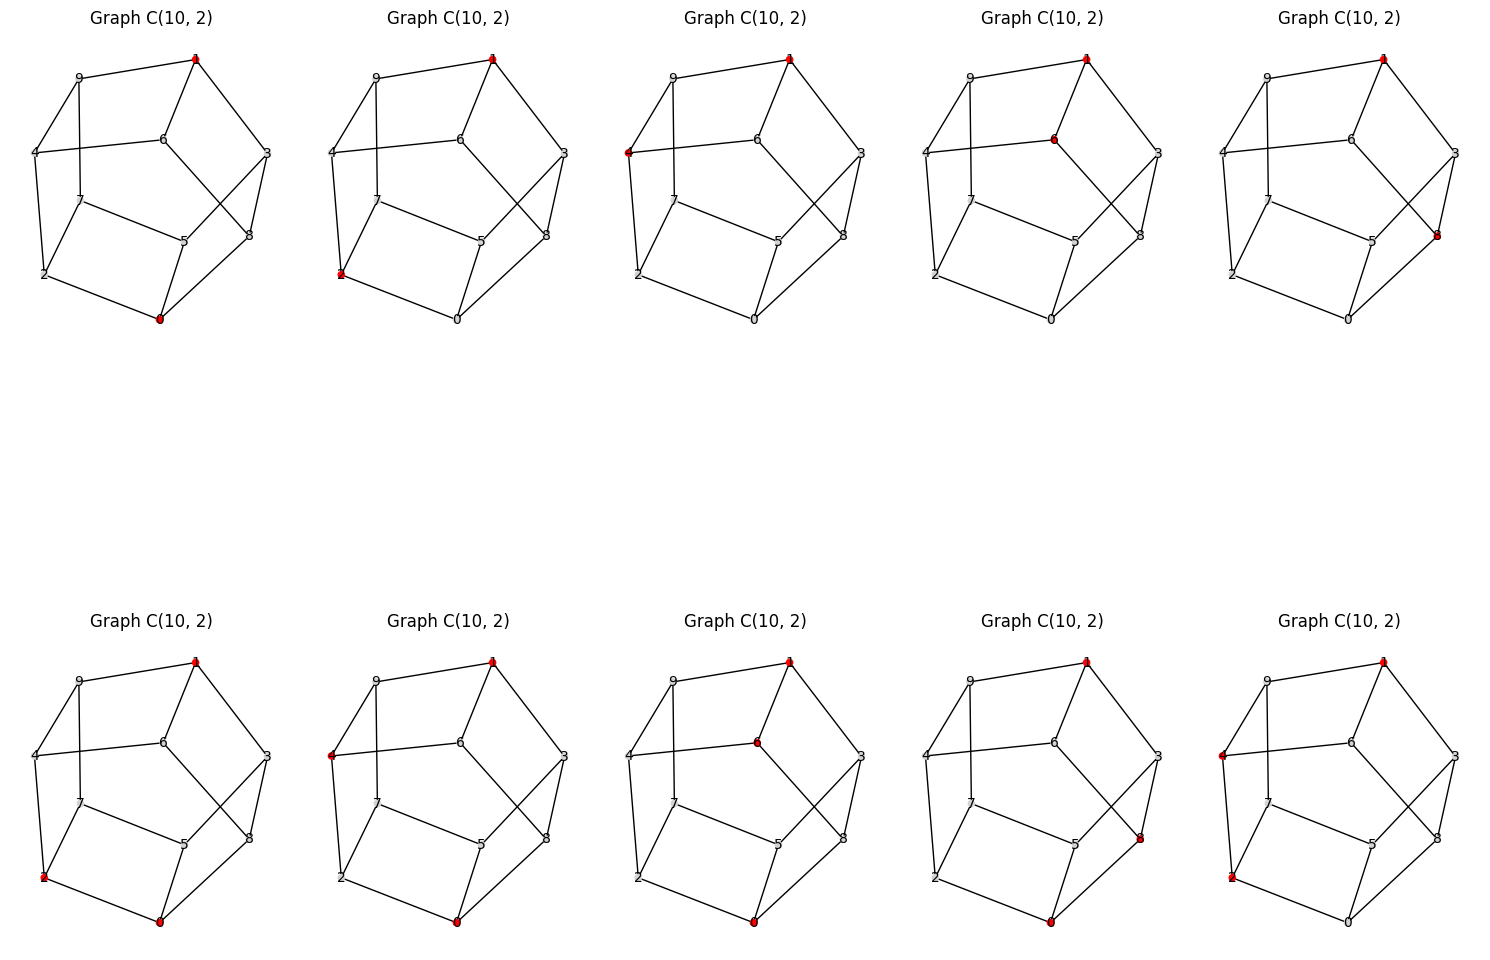

[1, 0, 0, 0, 0, 0, 1, 0, 0, 1]
[1, 0, 0, 0, 0, 0, 0, 1, 1, 0]
[1, 0, 0, 0, 0, 0, 0, 1, 0, 1]
[1, 0, 0, 0, 0, 0, 0, 0, 1, 1]
[1, 1, 0, 0, 0, 1, 0, 0, 0, 0]
[1, 1, 0, 0, 0, 0, 1, 0, 0, 0]
[1, 1, 0, 0, 0, 0, 0, 1, 0, 0]
[1, 1, 0, 0, 0, 0, 0, 0, 1, 0]
[1, 1, 0, 0, 0, 0, 0, 0, 0, 1]
[1, 0, 0, 0, 0, 1, 1, 1, 0, 0]


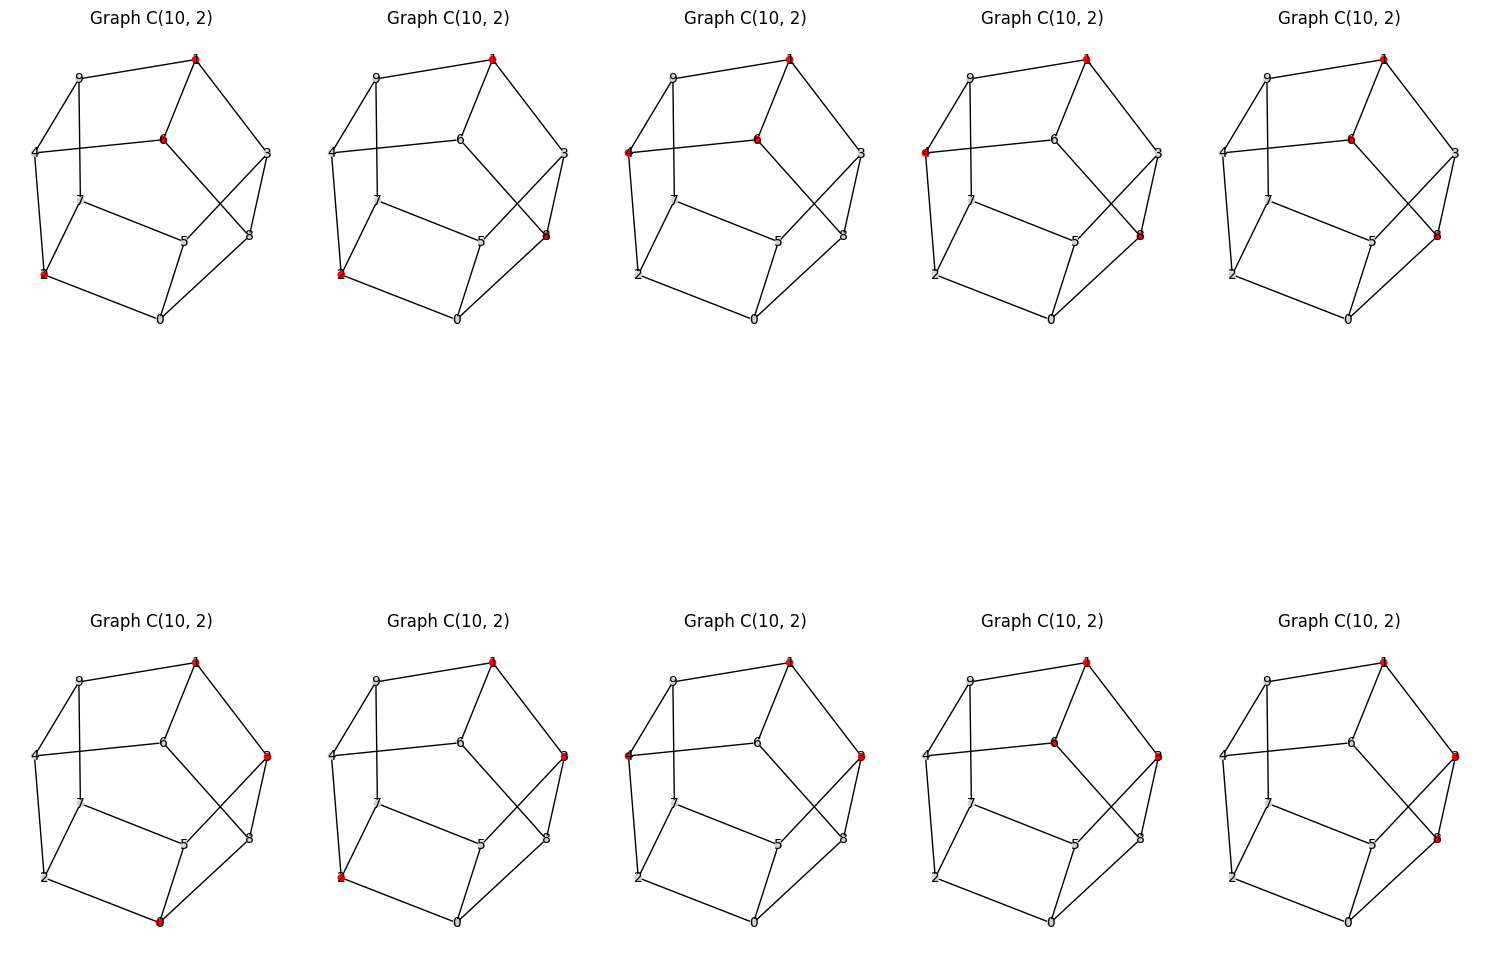

[1, 0, 0, 0, 0, 1, 1, 0, 1, 0]
[1, 0, 0, 0, 0, 1, 1, 0, 0, 1]
[1, 0, 0, 0, 0, 1, 0, 1, 1, 0]
[1, 0, 0, 0, 0, 1, 0, 1, 0, 1]
[1, 0, 0, 0, 0, 1, 0, 0, 1, 1]
[1, 0, 0, 0, 0, 0, 1, 1, 1, 0]
[1, 0, 0, 0, 0, 0, 1, 1, 0, 1]
[1, 0, 0, 0, 0, 0, 1, 0, 1, 1]
[1, 0, 0, 0, 0, 0, 0, 1, 1, 1]
[1, 1, 0, 0, 0, 1, 1, 0, 0, 0]


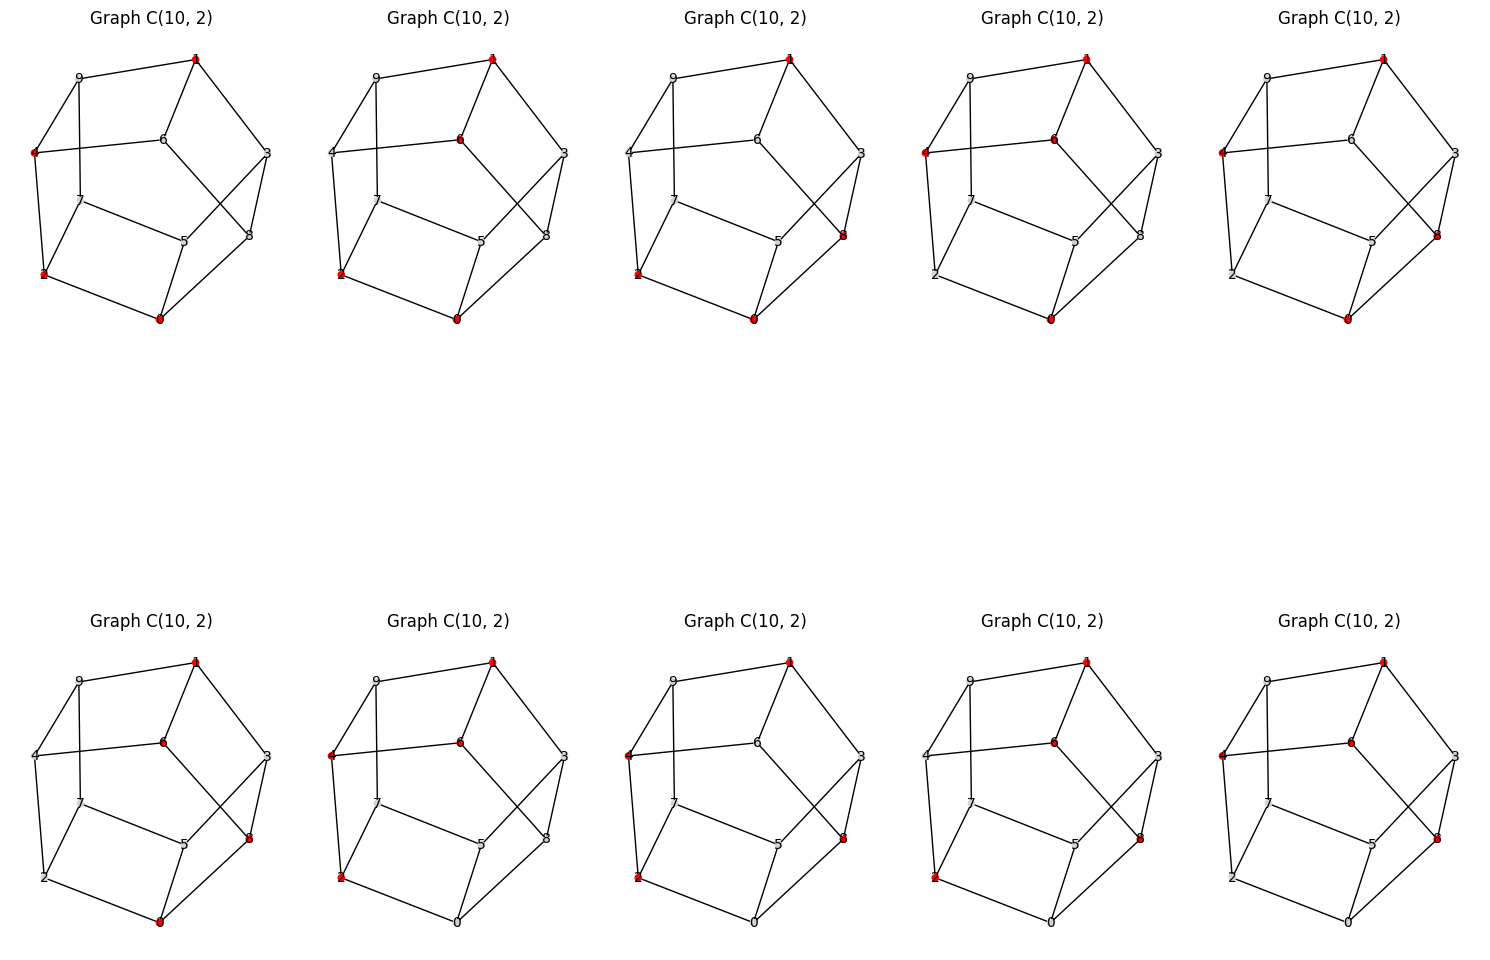

[1, 1, 0, 0, 0, 1, 0, 1, 0, 0]
[1, 1, 0, 0, 0, 1, 0, 0, 1, 0]
[1, 1, 0, 0, 0, 1, 0, 0, 0, 1]
[1, 1, 0, 0, 0, 0, 1, 1, 0, 0]
[1, 1, 0, 0, 0, 0, 1, 0, 1, 0]
[1, 1, 0, 0, 0, 0, 1, 0, 0, 1]
[1, 1, 0, 0, 0, 0, 0, 1, 1, 0]
[1, 1, 0, 0, 0, 0, 0, 1, 0, 1]
[1, 1, 0, 0, 0, 0, 0, 0, 1, 1]
[1, 1, 1, 0, 0, 1, 0, 0, 0, 0]


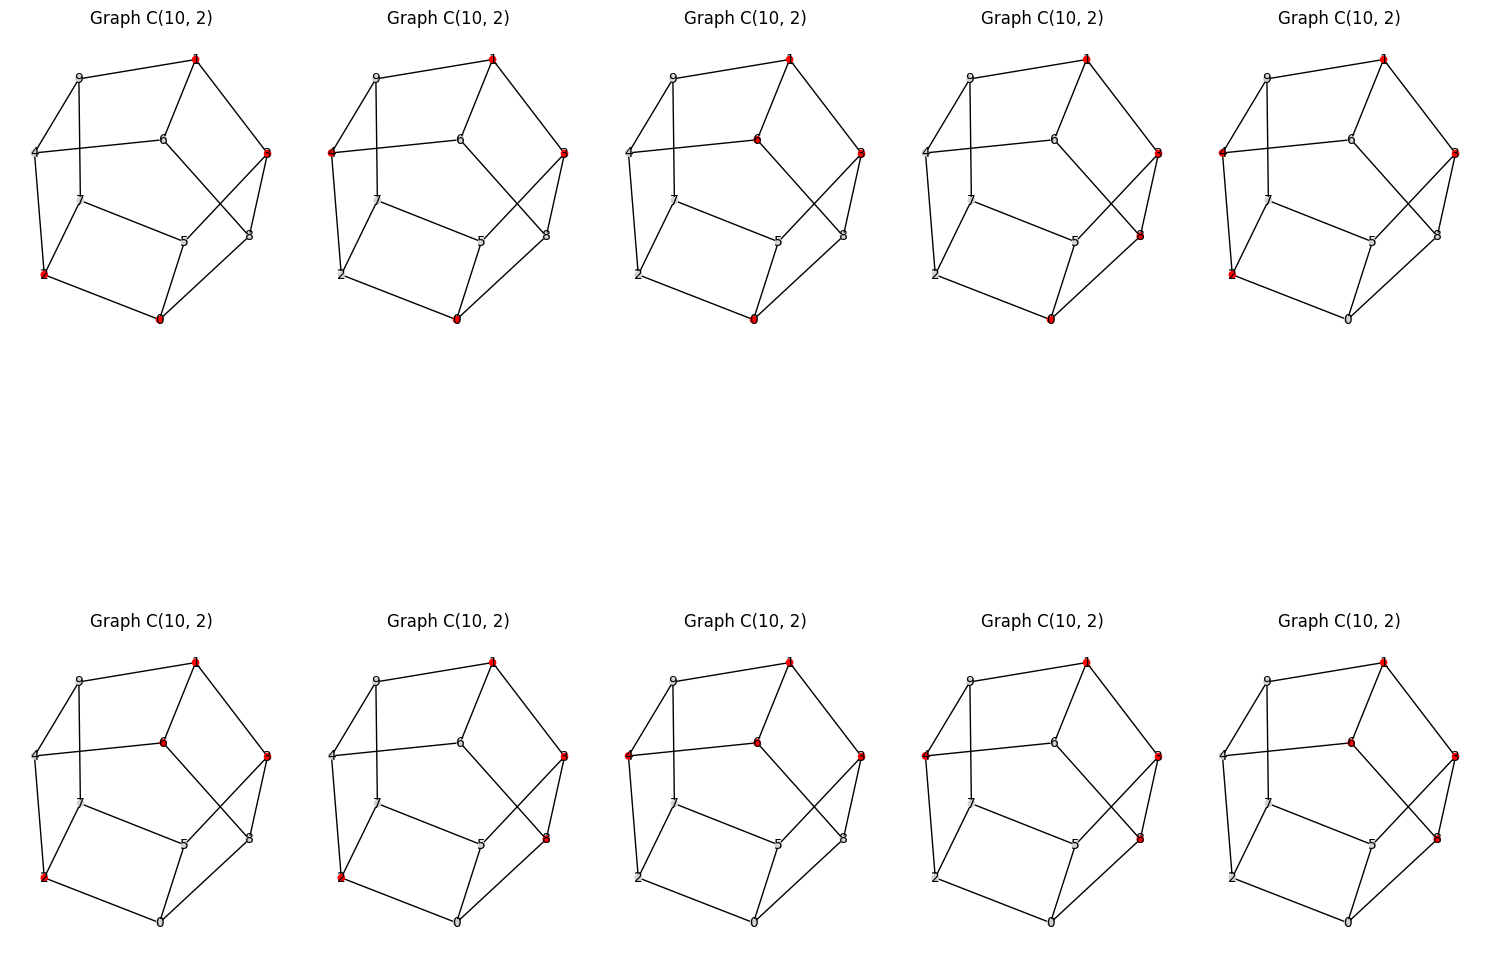

[1, 1, 1, 0, 0, 0, 1, 0, 0, 0]
[1, 1, 1, 0, 0, 0, 0, 1, 0, 0]
[1, 1, 1, 0, 0, 0, 0, 0, 1, 0]
[1, 1, 1, 0, 0, 0, 0, 0, 0, 1]
[1, 0, 0, 0, 0, 1, 1, 1, 1, 0]
[1, 0, 0, 0, 0, 1, 1, 1, 0, 1]
[1, 0, 0, 0, 0, 1, 1, 0, 1, 1]
[1, 0, 0, 0, 0, 1, 0, 1, 1, 1]
[1, 0, 0, 0, 0, 0, 1, 1, 1, 1]
[1, 1, 0, 0, 0, 1, 1, 1, 0, 0]


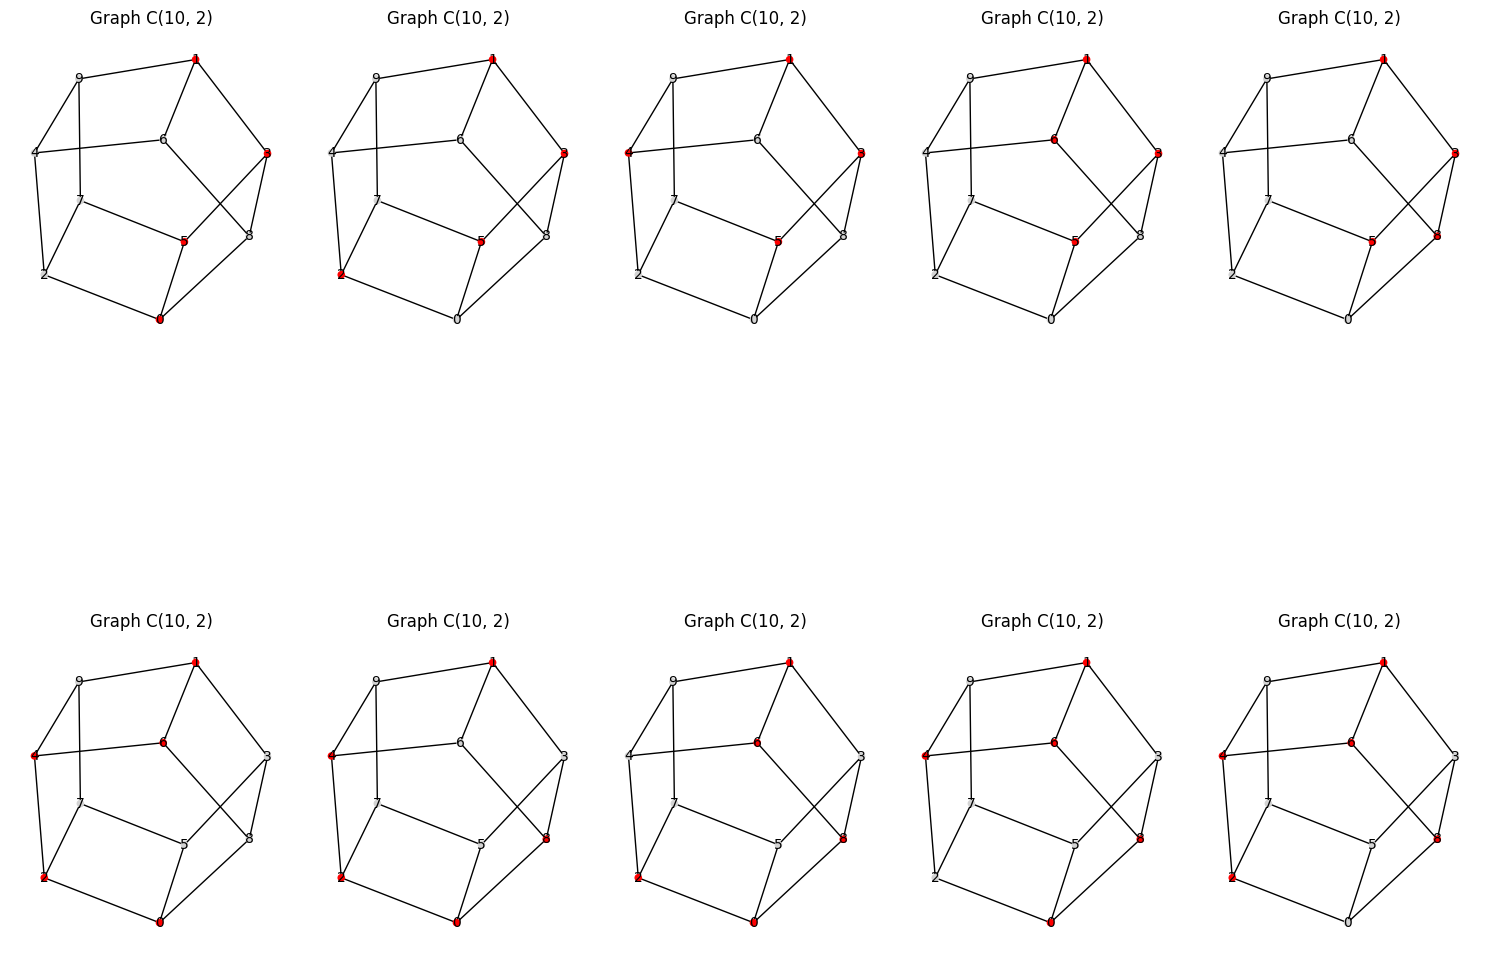

[1, 1, 0, 0, 0, 1, 1, 0, 1, 0]
[1, 1, 0, 0, 0, 1, 1, 0, 0, 1]
[1, 1, 0, 0, 0, 1, 0, 1, 1, 0]
[1, 1, 0, 0, 0, 1, 0, 1, 0, 1]
[1, 1, 0, 0, 0, 1, 0, 0, 1, 1]
[1, 1, 0, 0, 0, 0, 1, 1, 1, 0]
[1, 1, 0, 0, 0, 0, 1, 1, 0, 1]
[1, 1, 0, 0, 0, 0, 1, 0, 1, 1]
[1, 1, 0, 0, 0, 0, 0, 1, 1, 1]
[1, 1, 1, 0, 0, 1, 1, 0, 0, 0]


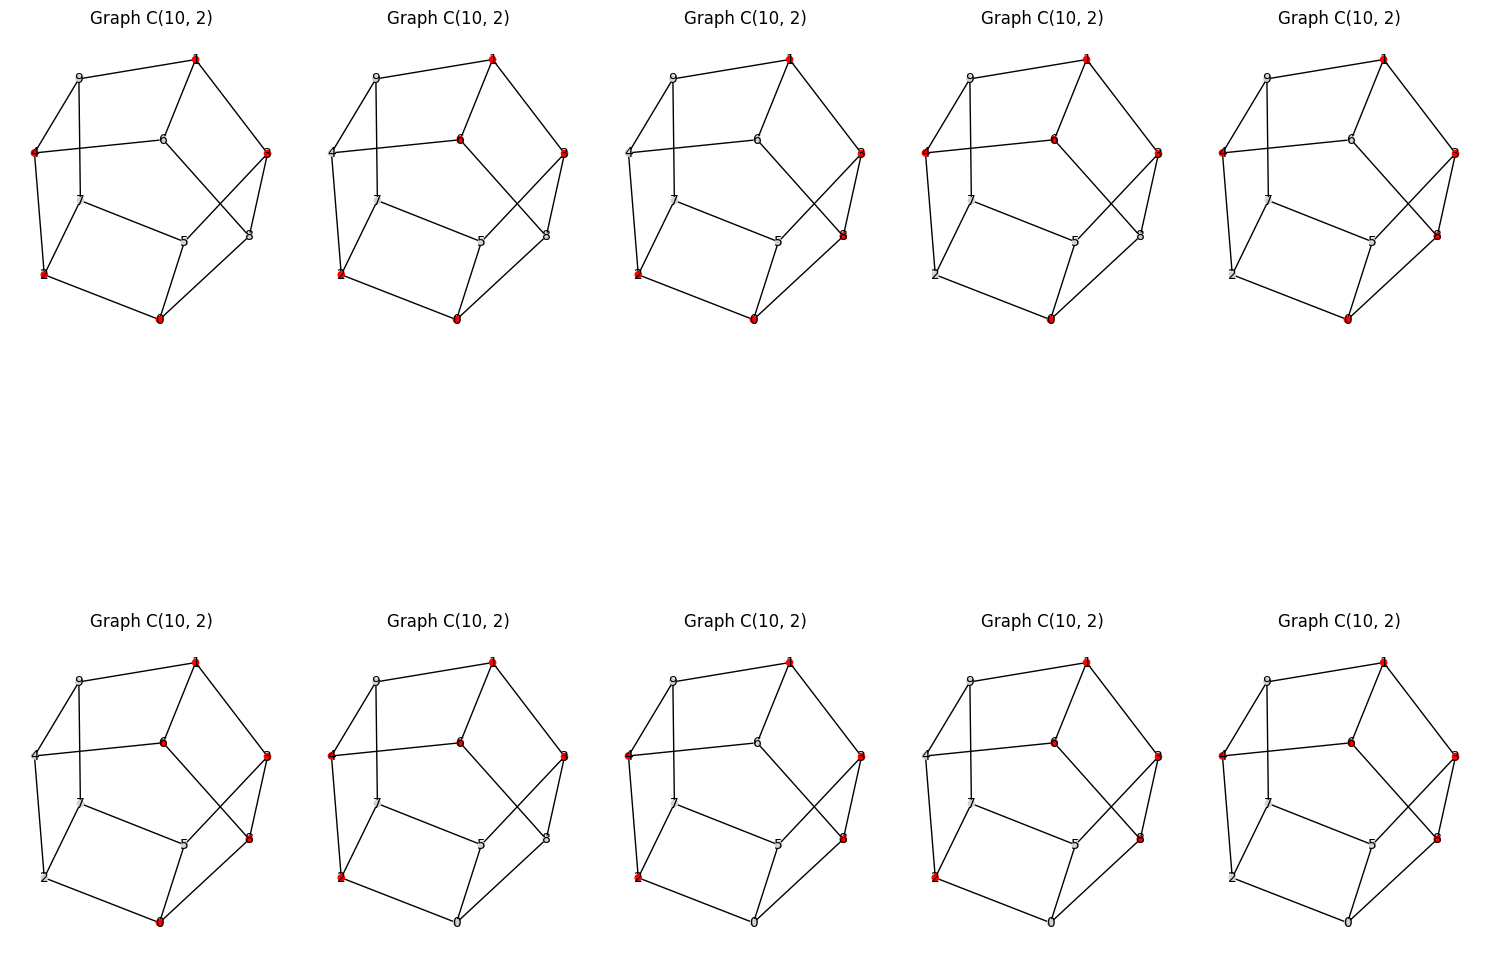

[1, 1, 1, 0, 0, 1, 0, 1, 0, 0]
[1, 1, 1, 0, 0, 1, 0, 0, 1, 0]
[1, 1, 1, 0, 0, 1, 0, 0, 0, 1]
[1, 1, 1, 0, 0, 0, 1, 1, 0, 0]
[1, 1, 1, 0, 0, 0, 1, 0, 1, 0]
[1, 1, 1, 0, 0, 0, 1, 0, 0, 1]
[1, 1, 1, 0, 0, 0, 0, 1, 1, 0]
[1, 1, 1, 0, 0, 0, 0, 1, 0, 1]
[1, 1, 1, 0, 0, 0, 0, 0, 1, 1]
[1, 1, 1, 1, 0, 1, 0, 0, 0, 0]


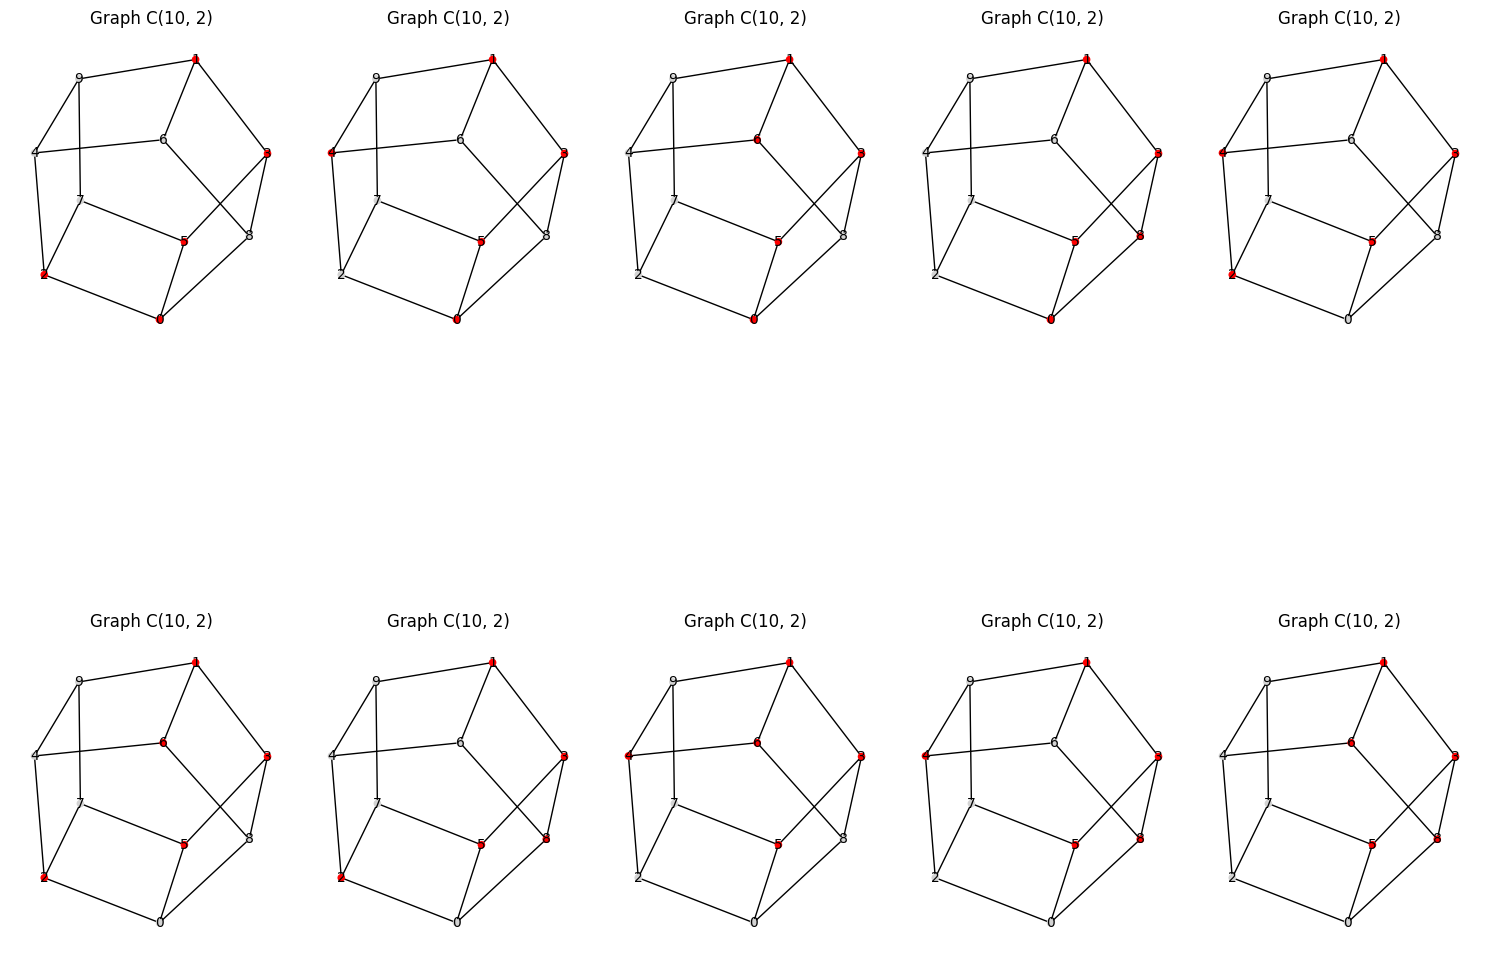

[1, 1, 1, 1, 0, 0, 1, 0, 0, 0]
[1, 1, 1, 1, 0, 0, 0, 1, 0, 0]
[1, 1, 1, 1, 0, 0, 0, 0, 1, 0]
[1, 1, 1, 1, 0, 0, 0, 0, 0, 1]
[1, 0, 0, 0, 0, 1, 1, 1, 1, 1]
[1, 1, 0, 0, 0, 1, 1, 1, 1, 0]
[1, 1, 0, 0, 0, 1, 1, 1, 0, 1]
[1, 1, 0, 0, 0, 1, 1, 0, 1, 1]
[1, 1, 0, 0, 0, 1, 0, 1, 1, 1]
[1, 1, 0, 0, 0, 0, 1, 1, 1, 1]


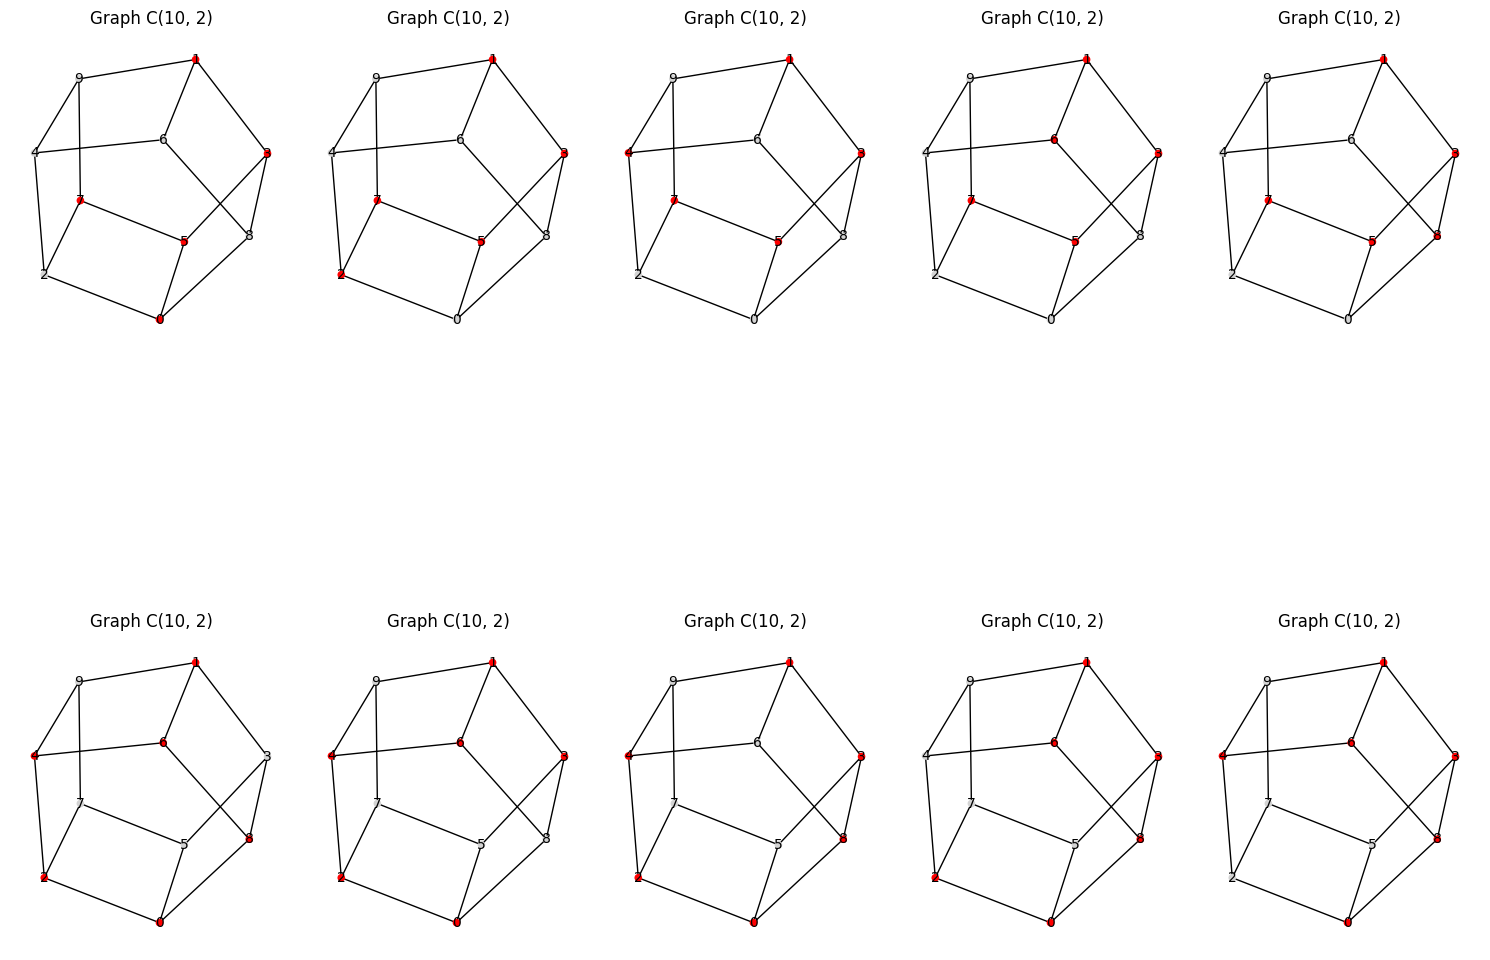

[1, 1, 1, 0, 0, 1, 1, 1, 0, 0]
[1, 1, 1, 0, 0, 1, 1, 0, 1, 0]
[1, 1, 1, 0, 0, 1, 1, 0, 0, 1]
[1, 1, 1, 0, 0, 1, 0, 1, 1, 0]
[1, 1, 1, 0, 0, 1, 0, 1, 0, 1]
[1, 1, 1, 0, 0, 1, 0, 0, 1, 1]
[1, 1, 1, 0, 0, 0, 1, 1, 1, 0]
[1, 1, 1, 0, 0, 0, 1, 1, 0, 1]
[1, 1, 1, 0, 0, 0, 1, 0, 1, 1]
[1, 1, 1, 0, 0, 0, 0, 1, 1, 1]


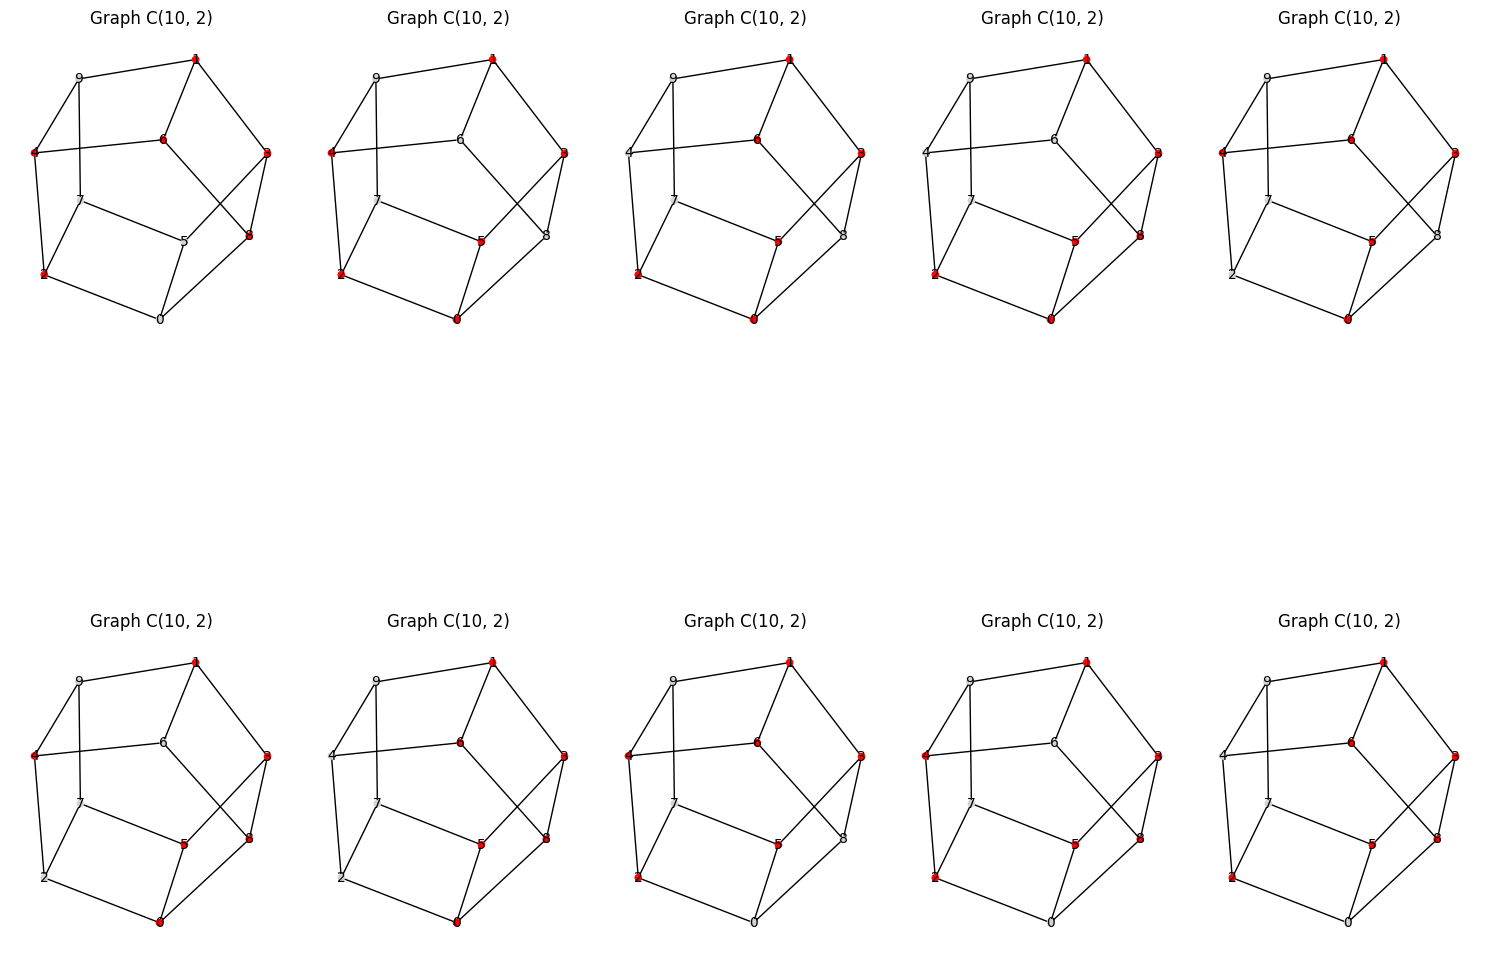

[1, 1, 1, 1, 0, 1, 1, 0, 0, 0]
[1, 1, 1, 1, 0, 1, 0, 1, 0, 0]
[1, 1, 1, 1, 0, 1, 0, 0, 1, 0]
[1, 1, 1, 1, 0, 1, 0, 0, 0, 1]
[1, 1, 1, 1, 0, 0, 1, 1, 0, 0]
[1, 1, 1, 1, 0, 0, 1, 0, 1, 0]
[1, 1, 1, 1, 0, 0, 1, 0, 0, 1]
[1, 1, 1, 1, 0, 0, 0, 1, 1, 0]
[1, 1, 1, 1, 0, 0, 0, 1, 0, 1]
[1, 1, 1, 1, 0, 0, 0, 0, 1, 1]


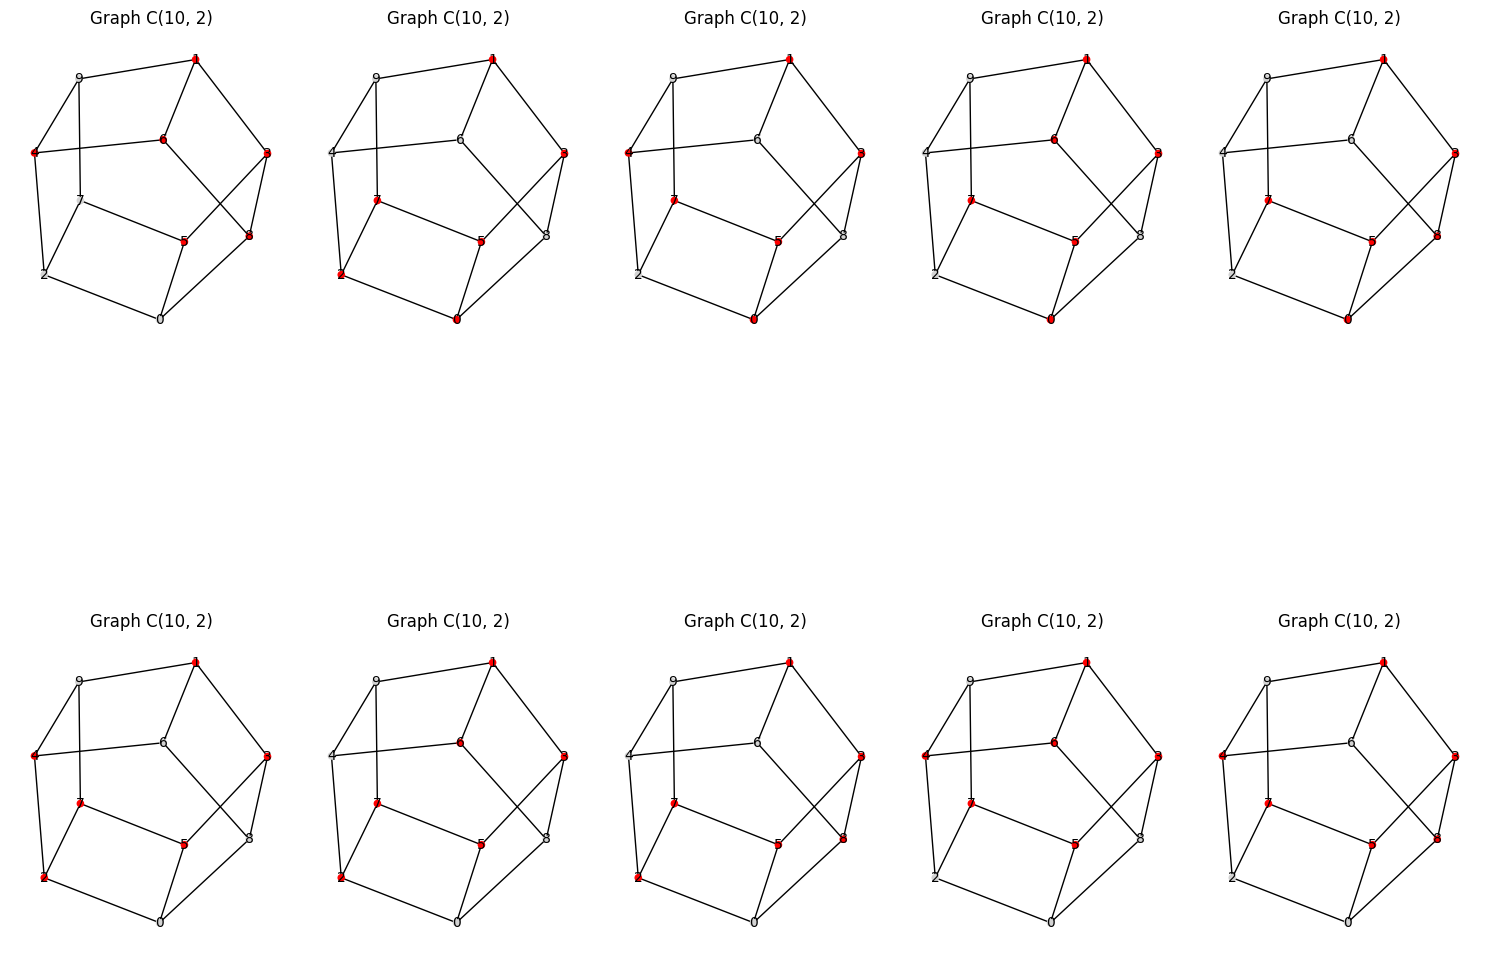

In [100]:
def infect_graph_by_cycle(G_, mask):
    G = G_.copy()

    M_top, M_bottom = split_mask(G, mask)
    C_top, C_bottom = get_cycles(G)

    for m, v in zip(M_top, sorted(C_top.nodes)):
        if m:
            G.nodes[v]["infected"] = 1

    for m, v in zip(M_bottom, sorted(C_bottom.nodes)):
        if m:
            G.nodes[v]["infected"] = 1

    return G




graph_list = []

i = 0
for im in generate_infection_prism2(G):
    G_i = infect_graph_by_cycle(G, im)
    print(im)

    # G_i = infect_graph(G, im)
    if i > 0 and i % 10 == 0:
        display_graphs(graph_list, figsize=(15, 15), show_titles=True, force_row=False, with_labels=True)
        graph_list = []
    
    graph_list.append((G_i, len(G.nodes), 2))
    i+=1

    if i > 100:
        break